In [ ]:
import os

if not os.path.exists("brain_tumor_dataset.zip"):
    from google.colab import files
    uploaded = files.upload()
else:
    print("Zip already exists, skipping upload")

In [ ]:
import zipfile
import os

zip_path = "brain_tumor_dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Done!")

Done!


In [ ]:
import os

base_path = "/content/dataset"

for root, dirs, files in os.walk(base_path):
    print(root)
    break

/content/dataset


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
train_dir = "/content/dataset/brain_tumor_dataset/Training"
test_dir  = "/content/dataset/brain_tumor_dataset/Testing"

img_size = 224
batch_size = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = train_data.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [ ]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

model_resnet.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 24,060,164 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
history_resnet = model_resnet.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 162s 577ms/step - accuracy: 0.6873 - loss: 0.7880 - val_accuracy: 0.2488 - val_loss: 1.7409
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 96s 546ms/step - accuracy: 0.8662 - loss: 0.3767 - val_accuracy: 0.2544 - val_loss: 1.7876
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 100s 569ms/step - accuracy: 0.9077 - loss: 0.2591 - val_accuracy: 0.2925 - val_loss: 1.6708
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 543ms/step - accuracy: 0.9354 - loss: 0.1902 - val_accuracy: 0.4106 - val_loss: 1.3959
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 142s 545ms/step - accuracy: 0.9511 - loss: 0.1496 - val_accuracy: 0.5900 - val_loss: 1.0176
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 543ms/step - accuracy: 0.9586 - loss: 0.1236 - val_accuracy: 0.8094 - val_loss: 0.5670
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 544ms/step - accuracy: 0.9677 - loss: 0.1024 - val_accuracy: 0.8338 - val_loss: 0.5386
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 543ms/step - accuracy: 0.9671 - loss

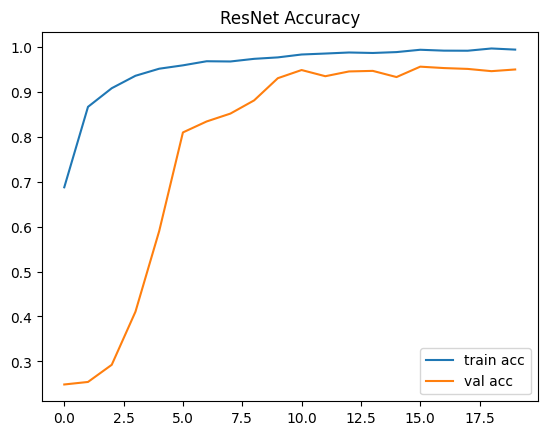

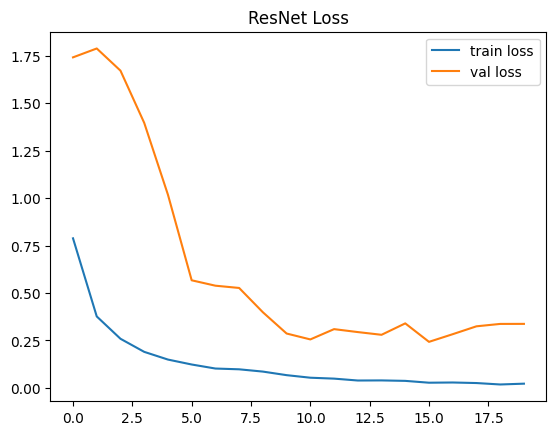

In [ ]:
plt.plot(history_resnet.history['accuracy'], label='train acc')
plt.plot(history_resnet.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("ResNet Accuracy")
plt.show()

plt.plot(history_resnet.history['loss'], label='train loss')
plt.plot(history_resnet.history['val_loss'], label='val loss')
plt.legend()
plt.title("ResNet Loss")
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step


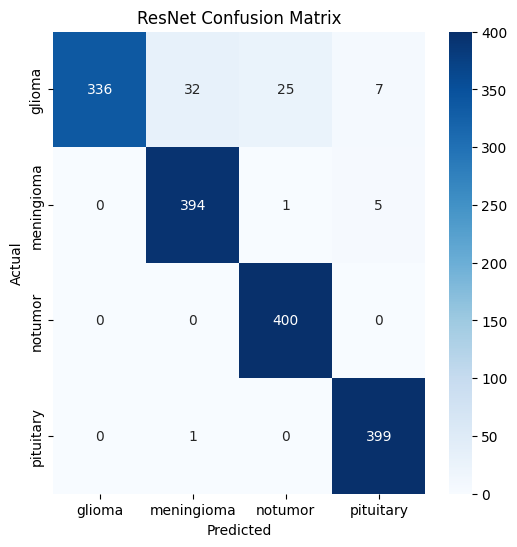

In [ ]:
y_pred = model_resnet.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_data.classes, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("ResNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(test_data.classes, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

      glioma       1.00      0.84      0.91       400
  meningioma       0.92      0.98      0.95       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.97      1.00      0.98       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.95      1600
weighted avg       0.96      0.96      0.95      1600



In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model_eff = Model(inputs=base_model.input, outputs=output)

In [ ]:
model_eff.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_eff = model_eff.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 419ms/step - accuracy: 0.2862 - loss: 1.7390 - val_accuracy: 0.2500 - val_loss: 1.6371
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 425ms/step - accuracy: 0.3021 - loss: 1.6749 - val_accuracy: 0.2500 - val_loss: 1.4906
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 422ms/step - accuracy: 0.3089 - loss: 1.6033 - val_accuracy: 0.2500 - val_loss: 1.4086
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 414ms/step - accuracy: 0.3411 - loss: 1.5294 - val_accuracy: 0.2900 - val_loss: 1.4007
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 417ms/step - accuracy: 0.3368 - loss: 1.5132 - val_accuracy: 0.3244 - val_loss: 1.3379
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 420ms/step - accuracy: 0.3320 - loss: 1.4978 - val_accuracy: 0.2994 - val_loss: 1.3509
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 421ms/step - accuracy: 0.3455 - loss: 1.4733 - val_accuracy: 0.3075 - val_loss: 1.3294
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 422ms/step - accuracy: 0.3482 - loss: 1

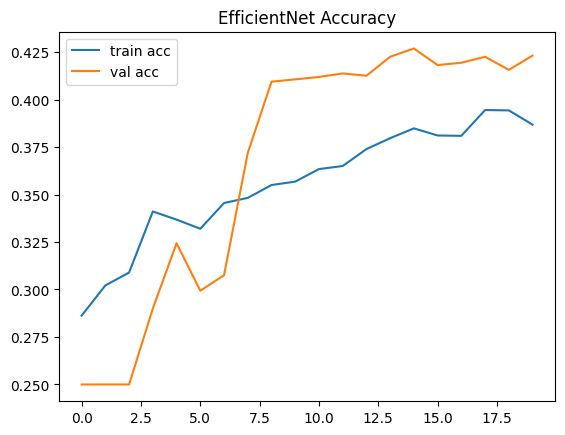

In [ ]:
plt.plot(history_eff.history['accuracy'], label='train acc')
plt.plot(history_eff.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("EfficientNet Accuracy")
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step


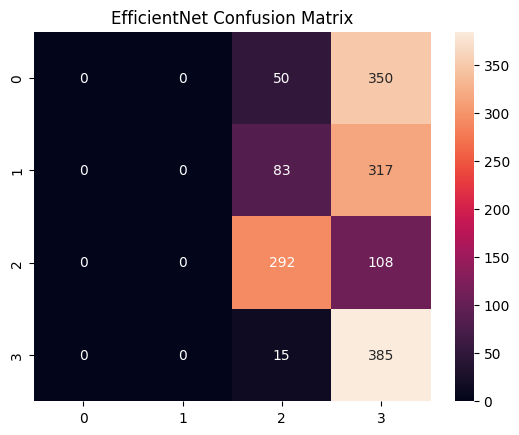

In [ ]:
y_pred = model_eff.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_data.classes, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("EfficientNet Confusion Matrix")
plt.show()

In [ ]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import (
    Dense, Flatten, Dropout,
    GlobalAveragePooling2D,
    Conv2D, MaxPooling2D
)
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_cnn = model_cnn.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 439ms/step - accuracy: 0.5048 - loss: 1.4474 - val_accuracy: 0.5000 - val_loss: 1.2665
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 428ms/step - accuracy: 0.5254 - loss: 1.1144 - val_accuracy: 0.4800 - val_loss: 1.1139
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 431ms/step - accuracy: 0.5557 - loss: 1.0561 - val_accuracy: 0.5906 - val_loss: 1.1015
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 433ms/step - accuracy: 0.5562 - loss: 1.0173 - val_accuracy: 0.5456 - val_loss: 1.4848
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 437ms/step - accuracy: 0.5895 - loss: 0.9615 - val_accuracy: 0.6612 - val_loss: 1.1014
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 431ms/step - accuracy: 0.5907 - loss: 0.9231 - val_accuracy: 0.6706 - val_loss: 1.4187
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 426ms/step - accuracy: 0.6164 - loss: 0.8974 - val_accuracy: 0.4663 - val_loss: 1.6072
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 447ms/step - accuracy: 0.6554 - loss: 0

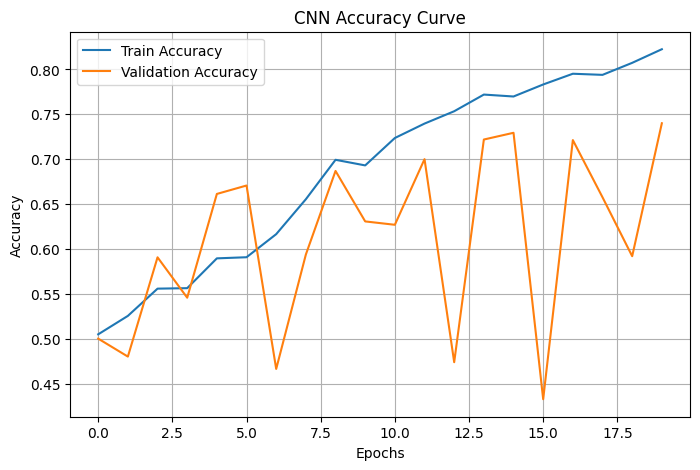

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Curve")
plt.legend()
plt.grid()

plt.show()

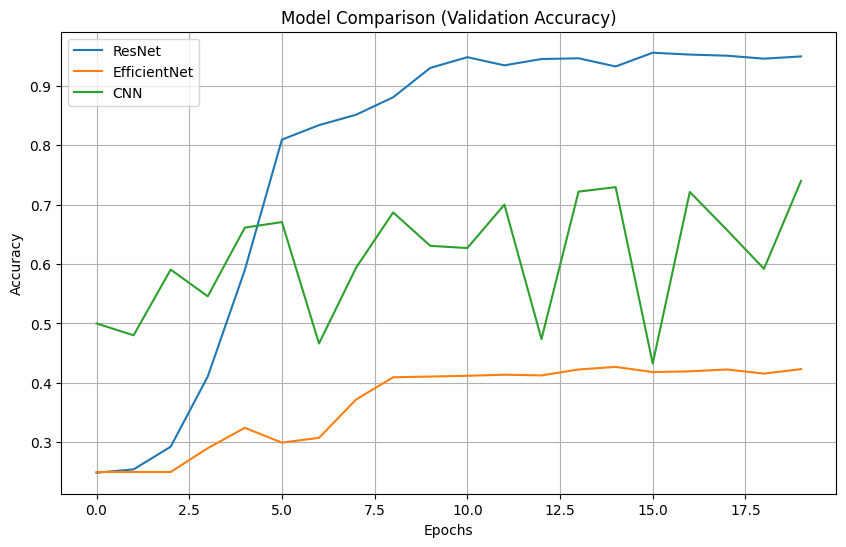

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_resnet.history['val_accuracy'], label='ResNet')
plt.plot(history_eff.history['val_accuracy'], label='EfficientNet')
plt.plot(history_cnn.history['val_accuracy'], label='CNN')

plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path, model):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)

    return class_idx, pred

In [ ]:
img_path = "/content/dataset/brain_tumor_dataset/Testing/glioma/Te-gl_17.jpg"

class_idx, pred = predict_image(img_path, model_resnet)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


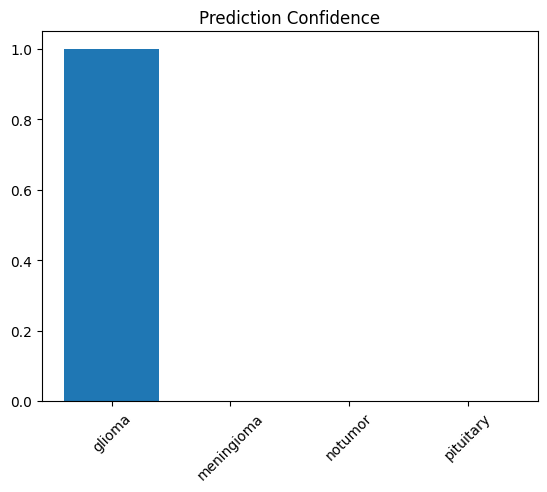

In [ ]:
plt.bar(class_names, pred[0])
plt.title("Prediction Confidence")
plt.xticks(rotation=45)
plt.show()

In [ ]:
model_resnet.save("/content/resnet_model.h5")
model_eff.save("/content/efficientnet_model.h5")
model_cnn.save("/content/cnn_model.h5")

print("Models saved!")

Models saved!


In [7]:
from google.colab import files

files.download("/content/final_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("/content/resnet_model.h5")
files.download("/content/efficientnet_model.h5")
files.download("/content/cnn_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

class_labels = train_data.class_indices

with open("/content/class_labels.json", "w") as f:
    json.dump(class_labels, f)

files.download("/content/class_labels.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path, model):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)

    return class_idx, pred

In [ ]:
test_img = "/content/dataset/brain_tumor_dataset/Testing/glioma/Te-gl_19.jpg"

class_idx, pred = predict_image(test_img, model_resnet)

print("Predicted Class Index:", class_idx)
print("Confidence:", np.max(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Class Index: 0
Confidence: 0.90035987


In [ ]:
class_names = list(train_data.class_indices.keys())

def get_label(idx):
    return class_names[idx]

print("Prediction:", get_label(class_idx))

Prediction: glioma


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model_resnet.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes

print("=== ResNet Report ===")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step
=== ResNet Report ===
              precision    recall  f1-score   support

      glioma       1.00      0.84      0.91       400
  meningioma       0.92      0.98      0.95       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.97      1.00      0.98       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.95      1600
weighted avg       0.96      0.96      0.95      1600



In [ ]:
y_pred_eff = model_eff.predict(test_data)
y_pred_eff_classes = np.argmax(y_pred_eff, axis=1)

print("=== EfficientNet Report ===")
print(classification_report(y_true, y_pred_eff_classes, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step
=== EfficientNet Report ===
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       400
  meningioma       0.00      0.00      0.00       400
     notumor       0.66      0.73      0.70       400
   pituitary       0.33      0.96      0.49       400

    accuracy                           0.42      1600
   macro avg       0.25      0.42      0.30      1600
weighted avg       0.25      0.42      0.30      1600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_pred_cnn = model_cnn.predict(test_data)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)

print("=== CNN Report ===")
print(classification_report(y_true, y_pred_cnn_classes, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step
=== CNN Report ===
              precision    recall  f1-score   support

      glioma       0.94      0.53      0.68       400
  meningioma       0.72      0.50      0.59       400
     notumor       0.77      0.94      0.84       400
   pituitary       0.65      1.00      0.79       400

    accuracy                           0.74      1600
   macro avg       0.77      0.74      0.72      1600
weighted avg       0.77      0.74      0.72      1600



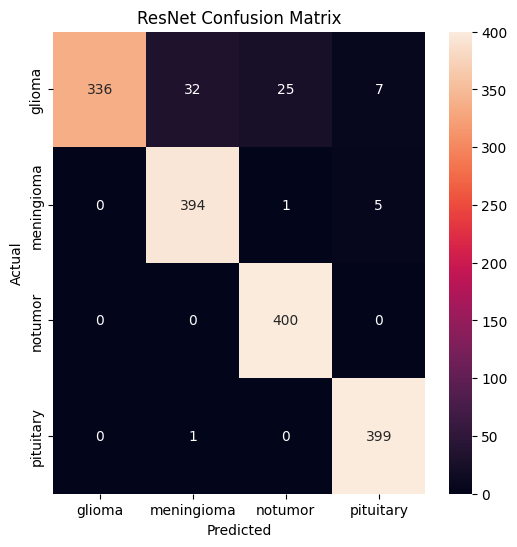

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("ResNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

print("ResNet Accuracy:", accuracy_score(y_true, y_pred_classes))
print("EffNet Accuracy:", accuracy_score(y_true, y_pred_eff_classes))
print("CNN Accuracy:", accuracy_score(y_true, y_pred_cnn_classes))

ResNet Accuracy: 0.955625
EffNet Accuracy: 0.423125
CNN Accuracy: 0.74


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam(model, img_array, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
from tensorflow.keras.preprocessing import image

img_path = "/content/dataset/brain_tumor_dataset/Testing/glioma/Te-gl_126.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

heatmap = get_gradcam(model_eff, img_array, last_conv_layer_name="top_conv")

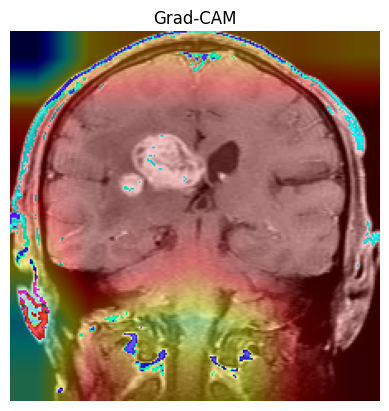

In [ ]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(superimposed_img.astype('uint8'))
plt.axis('off')
plt.title("Grad-CAM")
plt.show()